In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [2]:
import os
print(os.path.expanduser('~'))

C:\Users\Bruger


In [3]:
df = pd.read_csv(r'C:\Users\Bruger\Downloads\Cleaned_HospitalData.csv')

print(df.shape)   # should print (25000, 17)
df.head()

(25001, 28)


,age,Age_Start,Age_End,Age_Midpoint,time_in_hospital,Length_of_Stay,n_lab_procedures,Lab_Test_Intensity,n_procedures,n_medications,...,diag_2,diag_3,glucose_test,Glucose_Test_Clean,A1Ctest,change,diabetes_med,Diabetes_Med_Status,readmitted,Readmission_Flag
0,[70-80),70.0,80.0,75.0,8.0,Long Stay,72.0,High,1.0,18.0,...,Respiratory,Other,no,no,no,no,yes,On Medication,no,0
1,[70-80),70.0,80.0,75.0,3.0,Short Stay,34.0,Normal,2.0,13.0,...,Other,Other,no,no,no,no,yes,On Medication,no,0
2,[50-60),50.0,60.0,55.0,5.0,Medium Stay,45.0,High,0.0,18.0,...,Circulatory,Circulatory,no,no,no,yes,yes,On Medication,yes,1
3,[70-80),70.0,80.0,75.0,2.0,Short Stay,36.0,Normal,0.0,12.0,...,Other,Diabetes,no,no,no,yes,yes,On Medication,yes,1
4,[60-70),60.0,70.0,65.0,1.0,Short Stay,42.0,High,0.0,7.0,...,Circulatory,Respiratory,no,no,no,no,yes,On Medication,no,0


In [4]:
# Keeping the original 17 columns
cols_to_keep = ['age', 'time_in_hospital', 'n_lab_procedures', 'n_procedures',
                'n_medications', 'n_outpatient', 'n_inpatient', 'n_emergency',
                'medical_specialty', 'diag_1', 'diag_2', 'diag_3',
                'glucose_test', 'A1Ctest', 'change', 'diabetes_med', 'readmitted']

df = df[cols_to_keep]

print(df.shape) 
df.head()

(25001, 17)


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,[70-80),8.0,72.0,1.0,18.0,2.0,0.0,0.0,Missing,Circulatory,Respiratory,Other,no,no,no,yes,no
1,[70-80),3.0,34.0,2.0,13.0,0.0,0.0,0.0,Other,Other,Other,Other,no,no,no,yes,no
2,[50-60),5.0,45.0,0.0,18.0,0.0,0.0,0.0,Missing,Circulatory,Circulatory,Circulatory,no,no,yes,yes,yes
3,[70-80),2.0,36.0,0.0,12.0,1.0,0.0,0.0,Missing,Circulatory,Other,Diabetes,no,no,yes,yes,yes
4,[60-70),1.0,42.0,0.0,7.0,0.0,0.0,0.0,InternalMedicine,Other,Circulatory,Respiratory,no,no,no,yes,no


In [5]:
# Exploratory Data Analysis 

# Summary statistics for numeric columns
df.describe()

,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency
count,25000.00000,25000.00000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,4.45332,43.24076,1.352360,16.252400,0.366400,0.615960,0.186600
std,3.00147,19.81862,1.715179,8.060532,1.195478,1.177951,0.885873
min,1.00000,1.00000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2.00000,31.00000,0.000000,11.000000,0.000000,0.000000,0.000000
50%,4.00000,44.00000,1.000000,15.000000,0.000000,0.000000,0.000000
75%,6.00000,57.00000,2.000000,20.000000,0.000000,1.000000,0.000000
max,14.00000,113.00000,6.000000,79.000000,33.000000,15.000000,64.000000


In [6]:
# Checking Data Types & Missing Values
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

=== Data Types ===
age                   object
time_in_hospital     float64
n_lab_procedures     float64
n_procedures         float64
n_medications        float64
n_outpatient         float64
n_inpatient          float64
n_emergency          float64
medical_specialty     object
diag_1                object
diag_2                object
diag_3                object
glucose_test          object
A1Ctest               object
change                object
diabetes_med          object
readmitted            object
dtype: object

=== Missing Values ===
age                  1
time_in_hospital     1
n_lab_procedures     1
n_procedures         1
n_medications        1
n_outpatient         1
n_inpatient          1
n_emergency          1
medical_specialty    1
diag_1               1
diag_2               1
diag_3               1
glucose_test         1
A1Ctest              1
change               1
diabetes_med         1
readmitted           1
dtype: int64


In [7]:
# Dropping the missing value

df = df.dropna()
print(df.shape) 

(25000, 17)


Readmission counts:
            Count  Percentage
readmitted                   
no          13246        53.0
yes         11754        47.0


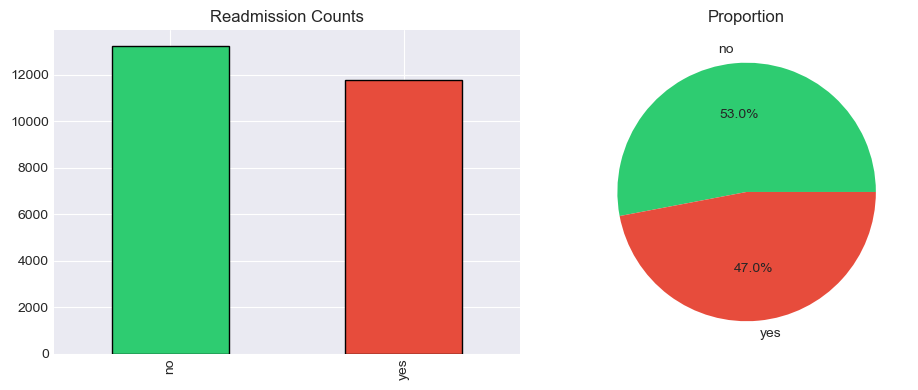

In [8]:
# Target variable distribution
# Count how many patients were readmitted/not
counts = df['readmitted'].value_counts()
pct    = df['readmitted'].value_counts(normalize=True) * 100

print("Readmission counts:")
print(pd.DataFrame({'Count': counts, 'Percentage': pct.round(1)}))

# Plot it
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'],
             edgecolor='black')
axes[0].set_title('Readmission Counts')
axes[0].set_xlabel('')

axes[1].pie(counts, labels=counts.index, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'])
axes[1].set_title('Proportion')

plt.tight_layout()
plt.show()

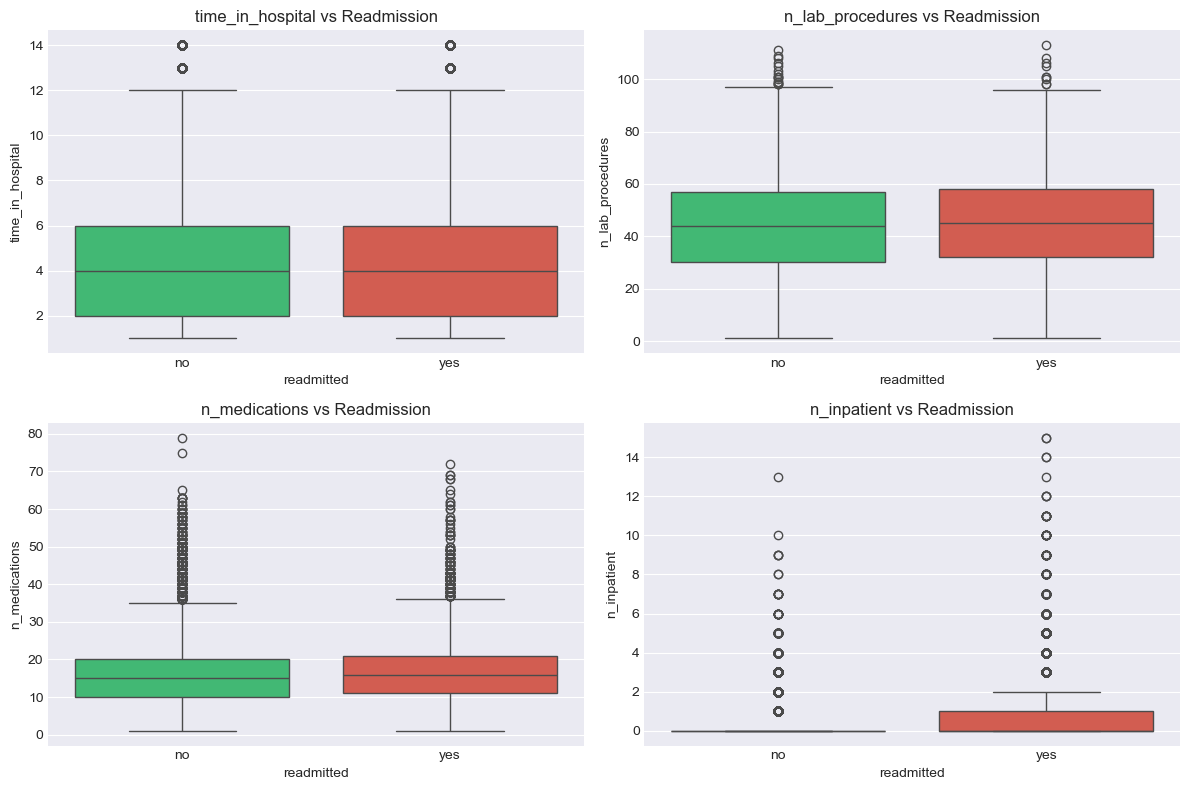

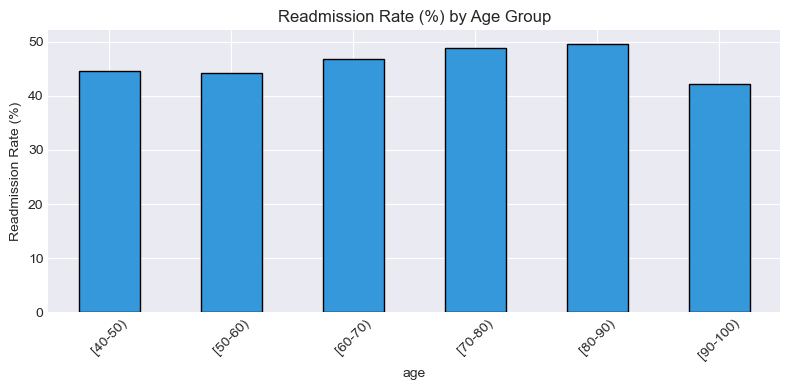

In [9]:
# Explore key features

# Numeric features compare distributions by readmission status

numeric_cols = ['time_in_hospital', 'n_lab_procedures',
                'n_medications', 'n_inpatient']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='readmitted', y=col,
            hue='readmitted',
            palette={'no': '#2ecc71', 'yes': '#e74c3c'},
            legend=False,
            ax=axes[i])
    axes[i].set_title(f'{col} vs Readmission')

plt.tight_layout()
plt.show()

# Categorical features readmission rate by age

age_readmit = df.groupby('age')['readmitted'].apply(
    lambda x: (x == 'yes').mean() * 100
).sort_index()

age_readmit.plot(kind='bar', figsize=(8, 4), color='#3498db',
                  edgecolor='black')
plt.title('Readmission Rate (%) by Age Group')
plt.ylabel('Readmission Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

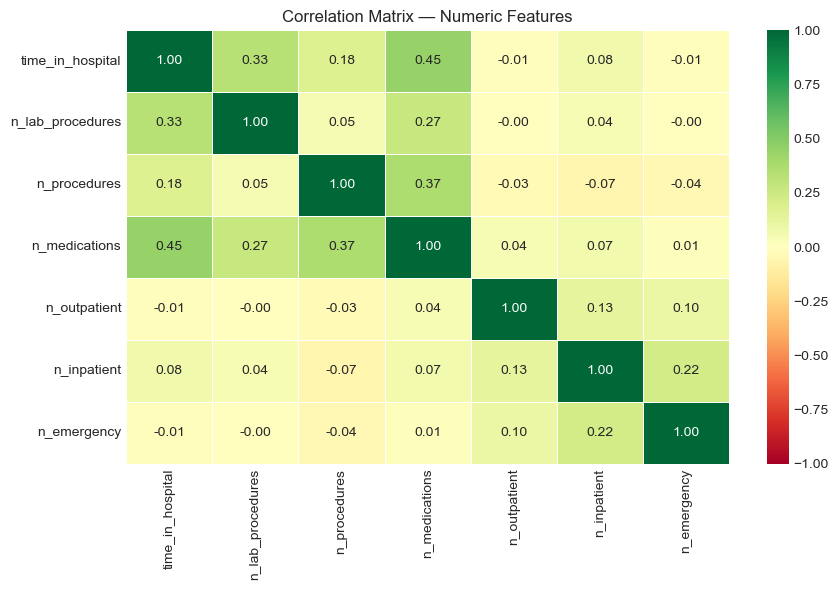

In [10]:
# Correlation Heatmap
# This shows how strongly numeric features relate to each other. Values close to +1 or -1 mean strong correlation.
# High correlation between features (multicollinearity) can sometimes
# hurt certain models  good to know before training!

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(9, 6))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
             cmap='RdYlGn', vmin=-1, vmax=1,
             linewidths=0.5)
plt.title('Correlation Matrix — Numeric Features')
plt.tight_layout()
plt.show()


In [14]:
# Data Preprocessing
# Raw data transformed into a format ML algorithms

# Work on a copy so we don't modify the original dataframe
df_model = df.copy()

# All columns that contain text (object dtype) need encoding
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('readmitted')   # handle target separately below

print(f"Categorical columns to encode: {cat_cols}")

le = LabelEncoder()

for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    print(f"  {col}: {le.classes_} → {le.transform(le.classes_)}")

print("\ Encoding complete")
df_model.head(3)

Categorical columns to encode: ['age', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'glucose_test', 'A1Ctest', 'change', 'diabetes_med']
  age: ['[40-50)' '[50-60)' '[60-70)' '[70-80)' '[80-90)' '[90-100)'] → [0 1 2 3 4 5]
  medical_specialty: ['Cardiology' 'Emergency/Trauma' 'Family/GeneralPractice'
 'InternalMedicine' 'Missing' 'Other' 'Surgery'] → [0 1 2 3 4 5 6]
  diag_1: ['Circulatory' 'Diabetes' 'Digestive' 'Injury' 'Missing' 'Musculoskeletal'
 'Other' 'Respiratory'] → [0 1 2 3 4 5 6 7]
  diag_2: ['Circulatory' 'Diabetes' 'Digestive' 'Injury' 'Missing' 'Musculoskeletal'
 'Other' 'Respiratory'] → [0 1 2 3 4 5 6 7]
  diag_3: ['Circulatory' 'Diabetes' 'Digestive' 'Injury' 'Missing' 'Musculoskeletal'
 'Other' 'Respiratory'] → [0 1 2 3 4 5 6 7]
  glucose_test: ['high' 'no' 'normal'] → [0 1 2]
  A1Ctest: ['high' 'no' 'normal'] → [0 1 2]
  change: ['no' 'yes'] → [0 1]
  diabetes_med: ['no' 'yes'] → [0 1]
\ Encoding complete


,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,diag_2,diag_3,glucose_test,A1Ctest,change,diabetes_med,readmitted
0,3,8.0,72.0,1.0,18.0,2.0,0.0,0.0,4,0,7,6,1,1,0,1,no
1,3,3.0,34.0,2.0,13.0,0.0,0.0,0.0,5,6,6,6,1,1,0,1,no
2,1,5.0,45.0,0.0,18.0,0.0,0.0,0.0,4,0,0,0,1,1,1,1,yes


In [15]:
# Convert 'no' → 0, 'yes' → 1
df_model['readmitted'] = (df_model['readmitted'] == 'yes').astype(int)

print("Target distribution after encoding:")
print(df_model['readmitted'].value_counts())
print(f"\nReadmission rate: {df_model['readmitted'].mean():.1%}")

Target distribution after encoding:
readmitted
0    13246
1    11754
Name: count, dtype: int64

Readmission rate: 47.0%


In [16]:
# Split into Features (X) and Target (y)
# X = all columns EXCEPT the target
# y = just the target column
X = df_model.drop(columns=['readmitted'])
y = df_model['readmitted']

print(f"Features shape: {X.shape}")   
print(f"Target shape:   {y.shape}") 

# Train/Test Split
# 80% for training, 20% for testing
# stratify=y ensures both splits have the same class ratio
# random_state=42 makes results reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nTraining set: {X_train.shape[0]:,} samples")
print(f"Test set:     {X_test.shape[0]:,} samples")

Features shape: (25000, 16)
Target shape:   (25000,)

Training set: 20,000 samples
Test set:     5,000 samples


In [17]:
# Choosing a Model Training the Model

# 1.Logistic Regression (Baseline)
# class_weight='balanced' automatically accounts for class imbalance
# max_iter=1000 gives the algorithm enough steps to converge

log_reg = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)   # ← this is where learning happens
print("Logistic Regression trained!")

# Predict on test set
y_pred_lr = log_reg.predict(X_test)
y_prob_lr  = log_reg.predict_proba(X_test)[:, 1]  # probability of class 

Logistic Regression trained!


In [18]:
# 2.Random Forest
# n_estimators=100 → build 100 decision trees and vote

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1    # use all CPU cores
)

rf.fit(X_train, y_train)
print("Random Forest trained!")

y_pred_rf = rf.predict(X_test)
y_prob_rf  = rf.predict_proba(X_test)[:, 1]

Random Forest trained!


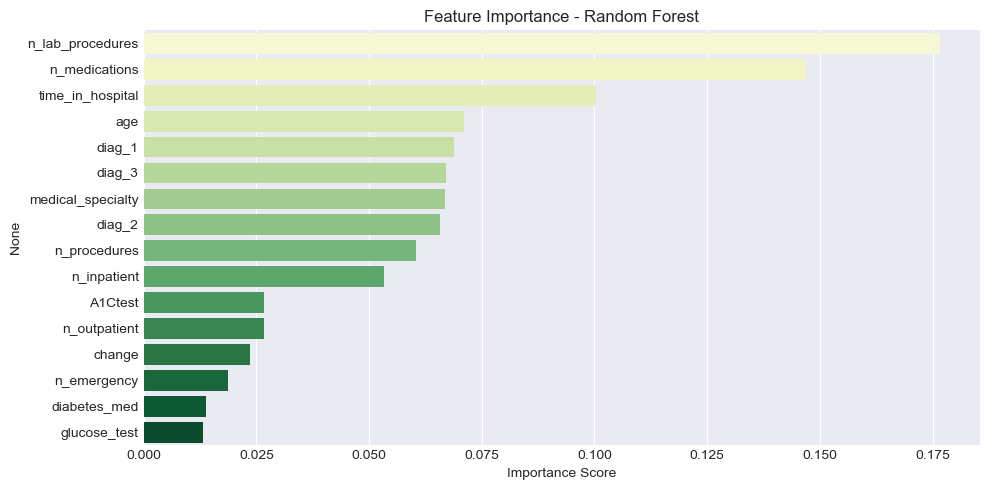


Top 5 most important features:
n_lab_procedures    0.176702
n_medications       0.146933
time_in_hospital    0.100408
age                 0.071143
diag_1              0.068955
dtype: float64


In [19]:
# Feature Importance (Random Forest)
# This shows which patient factors most predict readmission
# High importance for n_inpatient means prior admissions are a strong signal.

importances = pd.Series(rf.feature_importances_,
                          index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importances.values, y=importances.index,
            hue=importances.index,
            palette='YlGn',
            legend=False)
plt.title('Feature Importance - Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
print(importances.head(5))

In [20]:
# Classification Report  get a clear comparison of both models side by side

def evaluate_model(name, y_true, y_pred, y_prob):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(classification_report(y_true, y_pred,
          target_names=['Not Readmitted', 'Readmitted']))
    auc = roc_auc_score(y_true, y_prob)
    print(f"  ROC-AUC Score: {auc:.4f}")
    return auc

auc_lr = evaluate_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr)
auc_rf = evaluate_model("Random Forest",       y_test, y_pred_rf, y_prob_rf)


  Logistic Regression
                precision    recall  f1-score   support

Not Readmitted       0.61      0.73      0.66      2649
    Readmitted       0.61      0.47      0.53      2351

      accuracy                           0.61      5000
     macro avg       0.61      0.60      0.60      5000
  weighted avg       0.61      0.61      0.60      5000

  ROC-AUC Score: 0.6459

  Random Forest
                precision    recall  f1-score   support

Not Readmitted       0.61      0.68      0.64      2649
    Readmitted       0.59      0.51      0.54      2351

      accuracy                           0.60      5000
     macro avg       0.60      0.60      0.59      5000
  weighted avg       0.60      0.60      0.60      5000

  ROC-AUC Score: 0.6316


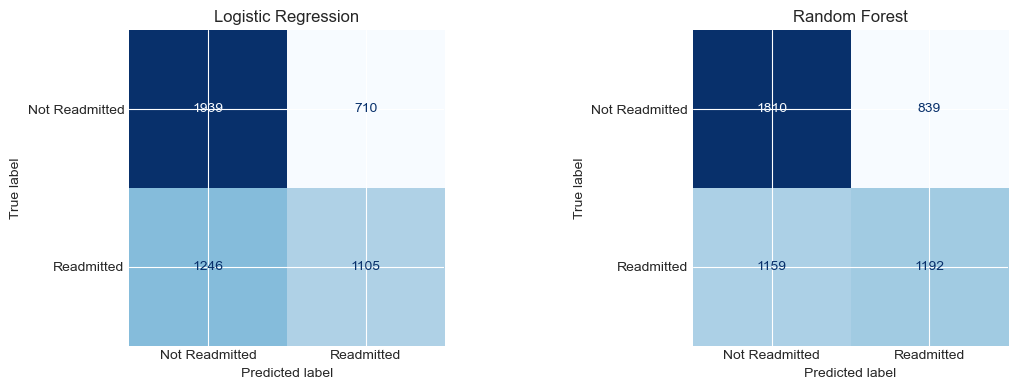

In [21]:
# Confusion Matrix     shows the 4 possible outcomes: True Positive, True Negative, False Positive, False Negative

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, y_pred) in zip(axes,
        [('Logistic Regression', y_pred_lr),
         ('Random Forest',       y_pred_rf)]):

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm,
               display_labels=['Not Readmitted', 'Readmitted'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.show()

# Reading the matrix (rows = actual, cols = predicted):
# Top-left  → Correctly predicted "not readmitted" (True Negative)
# Top-right → Incorrectly flagged as readmitted (False Positive)
# Bot-left  → Missed actual readmissions (False Negative) ← most costly!
# Bot-right → Correctly predicted readmissions (True Positive)

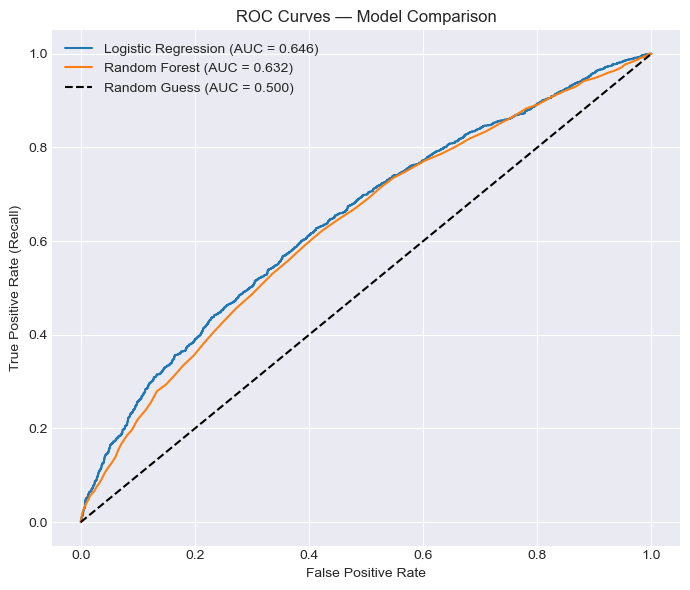

In [22]:
plt.figure(figsize=(7, 6))

for name, y_prob, auc in [
        ('Logistic Regression', y_prob_lr, auc_lr),
        ('Random Forest',       y_prob_rf, auc_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random Guess (AUC = 0.500)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curves — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

# The further the curve bows toward the top-left corner, the better.
# Dashed diagonal line = a model that just guesses randomly.